# Lecture 5c — From backtest to verdict

**AI-powered Investment and Risk Management**

The features are built. The labels are chosen. A model has been fitted and it reports an area under the ROC curve of 0.80.

This notebook is about the only question that remains, which is whether you have any reason to believe that number. We will take **one model, on one dataset, with one set of features**, and evaluate it four different ways. The answers will range from "publishable" to "nothing at all", and the difference will have nothing to do with the model.

**What you will be able to do afterwards**

- Name the three separate mechanisms by which random cross-validation leaks in financial data, and measure each
- Implement purging and embargoing, and say when each is required
- Explain why a permutation test does not detect the leak it is most often used to rule out
- Convert a directional accuracy into a Sharpe ratio through the fundamental law, and find the information coefficient at which costs eat the edge
- Compute the probability of backtest overfitting from a set of candidate strategies

**Runtime** — about three minutes; the permutation test in §3 is most of it.

---

In [16]:
# Colab: uncomment.
# !pip install -q ta plotly scikit-learn statsmodels

import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

import airm5 as a
from airm5 import C, style

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
rng = np.random.default_rng(0)

def model(fast=False):
    """One model specification, used unchanged throughout the notebook."""
    return HistGradientBoostingClassifier(
        max_depth=3, max_iter=60 if fast else 150,
        learning_rate=0.08 if fast else 0.05, random_state=0)

## 0. The setup, fixed once

Apple daily bars, the eighty-four cleaned indicators from Lecture 5b, and a five-day directional label. Nothing below changes any of this. Only the evaluation protocol changes.

In [17]:
ohlcv = a.load_ohlcv("AAPL")
X = a.ta_features(ohlcv)
H = 5

fwd = (ohlcv.Close.shift(-H) / ohlcv.Close - 1).reindex(X.index)
usable = fwd.notna()
X, fwd = X[usable], fwd[usable]
y = (fwd > 0).astype(int)

Xv, yv = X.values, y.values
Zv = ((X - X.mean()) / X.std()).values         # scaled on the full sample — deliberately

print(f"Feature matrix : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Label          : sign of the {H}-day forward return")
print(f"Base rate      : {y.mean():.1%} up")
print(f"Period         : {X.index[0].date()} to {X.index[-1].date()}")

Feature matrix : 1,183 rows × 84 features
Label          : sign of the 5-day forward return
Base rate      : 56.4% up
Period         : 2013-05-22 to 2018-01-31


## 1. The realism ladder

Four protocols, from the one a machine-learning course would teach to the one a trading desk would accept.

In [18]:
results = {}

# Rung 1 — random k-fold, features scaled on the full sample. The default recipe.
aucs = [roc_auc_score(yv[te], model().fit(Zv[tr], yv[tr]).predict_proba(Zv[te])[:, 1])
        for tr, te in KFold(5, shuffle=True, random_state=0).split(Zv)]
results["1. Random 5-fold CV"] = aucs

# Rung 2 — one chronological split. Nothing shuffled.
cut = int(len(X) * 0.7)
results["2. Single chronological split"] = [roc_auc_score(
    yv[cut:], model().fit(Xv[:cut], yv[:cut]).predict_proba(Xv[cut:])[:, 1])]

# Rung 3 — expanding-window walk-forward, six folds.
results["3. Walk-forward (6 folds)"] = [
    roc_auc_score(yv[te], model().fit(Xv[tr], yv[tr]).predict_proba(Xv[te])[:, 1])
    for tr, te in a.purged_walk_forward(len(X), n_splits=6, purge=0)]

# Rung 4 — the same, with training rows whose labels reach into the test block removed.
results["4. Purged walk-forward"] = [
    roc_auc_score(yv[te], model().fit(Xv[tr], yv[tr]).predict_proba(Xv[te])[:, 1])
    for tr, te in a.purged_walk_forward(len(X), n_splits=6, purge=H)]

ladder = pd.DataFrame({
    "Protocol": list(results),
    "Mean AUC": [np.mean(v) for v in results.values()],
    "Worst fold": [np.min(v) for v in results.values()],
    "Best fold": [np.max(v) for v in results.values()],
})
print(ladder.to_string(index=False))

                     Protocol  Mean AUC  Worst fold  Best fold
          1. Random 5-fold CV     0.811       0.765      0.870
2. Single chronological split     0.529       0.529      0.529
    3. Walk-forward (6 folds)     0.500       0.334      0.608
       4. Purged walk-forward     0.512       0.388      0.601


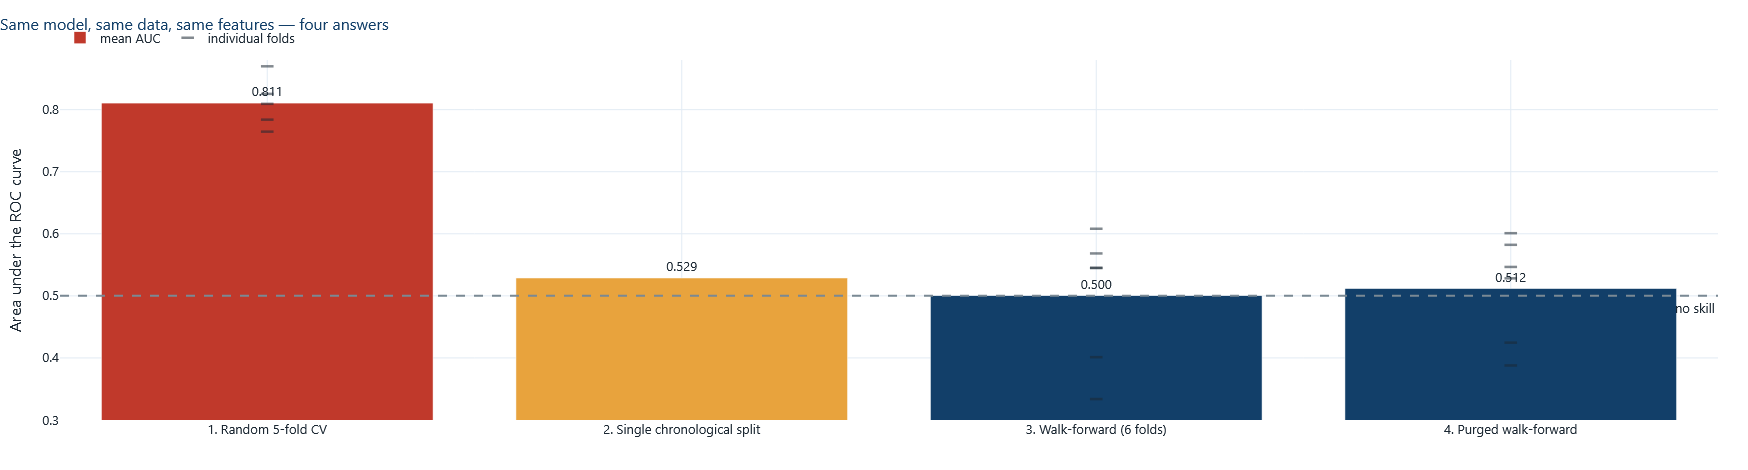

In [19]:
fig = go.Figure()
fig.add_trace(go.Bar(x=ladder.Protocol, y=ladder["Mean AUC"],
                     marker_color=[C["red"], C["amber"], C["navy"], C["navy"]],
                     text=[f"{v:.3f}" for v in ladder["Mean AUC"]],
                     textposition="outside", name="mean AUC"))
for i, (_, v) in enumerate(results.items()):
    if len(v) > 1:
        fig.add_trace(go.Scatter(x=[ladder.Protocol[i]] * len(v), y=v, mode="markers",
                                 marker=dict(size=9, color=C["ink"], opacity=0.55,
                                             symbol="line-ew-open",
                                             line=dict(width=2.5, color=C["ink"])),
                                 showlegend=(i == 0), name="individual folds"))
fig.add_hline(y=0.5, line=dict(color=C["grey"], width=2, dash="dash"),
              annotation_text="no skill", annotation_position="bottom right")
fig.update_yaxes(title="Area under the ROC curve", range=[0.3, 0.88])
style(fig, height=470,
      title="Same model, same data, same features — four answers")
fig.show()

An AUC of 0.803 is the kind of number that gets a model deployed. It is also, on this data, entirely an artefact of how the folds were drawn.

Two details in that chart deserve as much attention as the headline.

**The fold markers.** Once the evaluation is honest, individual folds range from about 0.36 to 0.60. Reporting the mean of six numbers that scattered as though it were a measurement is its own error — the standard error across folds is larger than the distance between the mean and 0.5.

**Purging barely moved it.** Rung 4 is very slightly *higher* than rung 3, which is noise, not a finding. Purging is necessary but it is not where the damage was. All of the damage happened at rung 1.

## 2. Three separate leaks, measured separately

"Random k-fold leaks in time series" is usually where the explanation stops. It is not one mechanism, it is three, and they are worth separating because they have different fixes.

1. **Shuffling.** Training rows drawn from after the test rows. The model sees the future directly.
2. **Overlapping labels.** The label at $t$ is built from returns over $t \ldots t{+}5$, and so shares four days with the label at $t{+}1$. Even without shuffling, adjacent rows are near-duplicates split across the train/test boundary.
3. **Full-sample scaling.** Standardising features using a mean and standard deviation computed over the whole period, including the test set.

In [20]:
def evaluate(shuffle, scale_full, purge):
    data = Zv if scale_full else Xv
    if shuffle:
        splits = list(KFold(5, shuffle=True, random_state=0).split(data))
    else:
        splits = list(a.purged_walk_forward(len(X), n_splits=5, purge=purge))
    out = []
    for tr, te in splits:
        d = data
        if not scale_full:                     # scale on the training block only
            mu, sd = data[tr].mean(0), data[tr].std(0) + 1e-12
            d = (data - mu) / sd
        out.append(roc_auc_score(yv[te], model().fit(d[tr], yv[tr]).predict_proba(d[te])[:, 1]))
    return float(np.mean(out))

combos = [("all three leaks",              True,  True,  0),
          ("shuffling removed",            False, True,  0),
          ("full-sample scaling removed",  True,  False, 0),
          ("shuffling + scaling fixed",    False, False, 0),
          ("all three fixed (purged)",     False, False, H)]
leak = pd.DataFrame([{"Protocol": n, "AUC": evaluate(s, f, p)} for n, s, f, p in combos])
leak["Damage vs clean"] = leak.AUC - leak.AUC.iloc[-1]
print(leak.to_string(index=False))

                   Protocol   AUC  Damage vs clean
            all three leaks 0.811            0.306
          shuffling removed 0.493           -0.011
full-sample scaling removed 0.811            0.306
  shuffling + scaling fixed 0.493           -0.012
   all three fixed (purged) 0.505            0.000


Shuffling is the whole story. Remove it and the AUC collapses immediately. Remove full-sample scaling while keeping shuffling and the result does not move at all — the same 0.803, to three decimal places.

That second result needs a caveat, because it is model-specific and the wrong lesson is easy to draw. A gradient-boosted tree splits on quantile bins, so rescaling a feature cannot change a single split; the scaler genuinely leaks nothing **here**. Fit a logistic regression, a support vector machine or a neural network and full-sample scaling would leak, because those models are not invariant to it. The general point stands regardless of which model you use: **the fold structure is where the damage is, and no amount of care inside the fold repairs a fold drawn wrongly.**

<details>
<summary><b>Why shuffling is so much more damaging here than in ordinary tabular data</b></summary>

Financial features are strongly autocorrelated: a 20-day moving average on consecutive days differs by one observation out of twenty. Adjacent rows are therefore near-duplicates. Under a random split, roughly 80% of each test row's immediate neighbours sit in the training set, so the model can very nearly look up the answer.

This is not overfitting in the usual sense — the model has genuinely learnt something that generalises to *shuffled* data. It has learnt to interpolate between neighbouring days. That skill is worthless out of sample, where there are no neighbouring days to interpolate from.
</details>

## 3. The permutation test will not save you

Suppose you are suspicious. You run a permutation test: shuffle the labels, refit, and see how often the model does as well by chance. It is the standard defence, and here it certifies the leak.

In [21]:
def kfold_auc(target):
    return np.mean([roc_auc_score(target[te], model(fast=True)
                    .fit(Zv[tr], target[tr]).predict_proba(Zv[te])[:, 1])
                    for tr, te in KFold(5, shuffle=True, random_state=0).split(Zv)])

observed = kfold_auc(yv)
N_PERM = 100
null = np.array([kfold_auc(rng.permutation(yv)) for _ in range(N_PERM)])
p_value = (np.sum(null >= observed) + 1) / (N_PERM + 1)

print(f"Observed AUC under the leaky protocol : {observed:.3f}")
print(f"Permutation null: mean {null.mean():.3f}, max {null.max():.3f}")
print(f"p-value ({N_PERM} permutations)              : {p_value:.3f}"
      f"{'  (floored by the number of permutations)' if p_value <= 1.5/(N_PERM+1) else ''}")
print(f"\nHonest walk-forward AUC for the same model: "
      f"{np.mean(results['4. Purged walk-forward']):.3f}")

Observed AUC under the leaky protocol : 0.776
Permutation null: mean 0.500, max 0.554
p-value (100 permutations)              : 0.010  (floored by the number of permutations)

Honest walk-forward AUC for the same model: 0.512


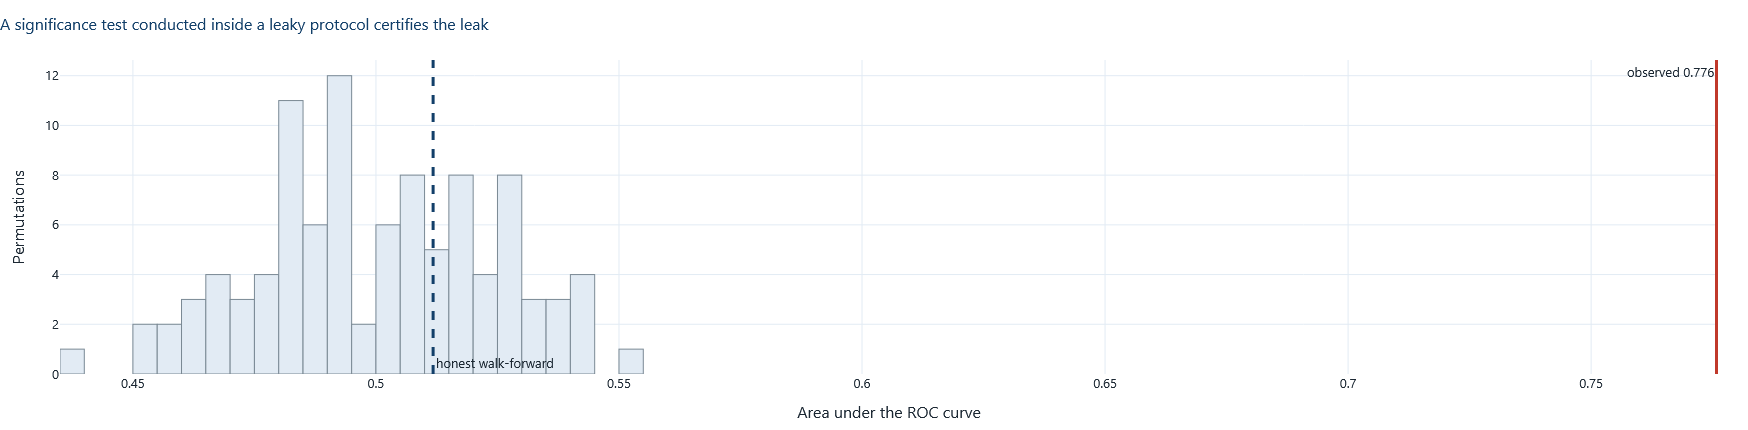

In [22]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=null, nbinsx=25, marker_color=C["band"],
                           marker_line=dict(color=C["grey"], width=1),
                           name="permuted labels"))
fig.add_vline(x=observed, line=dict(color=C["red"], width=3),
              annotation_text=f"observed {observed:.3f}", annotation_position="top left")
fig.add_vline(x=np.mean(results["4. Purged walk-forward"]),
              line=dict(color=C["navy"], width=3, dash="dash"),
              annotation_text="honest walk-forward", annotation_position="bottom right")
fig.update_xaxes(title="Area under the ROC curve")
fig.update_yaxes(title="Permutations")
style(fig, height=430, legend_top=False,
      title="A significance test conducted inside a leaky protocol certifies the leak")
fig.show()

The permutation test returns a decisively significant result for a model that has no measurable edge.

The reason is worth stating carefully, because it generalises well beyond this example. **Permuting the labels destroys the very structure that causes the leak.** The leak exists because $y_t$ and $y_{t+1}$ are dependent; shuffling $y$ removes that dependence, so the null distribution is built under a data-generating process that does not contain the problem you were testing for. The test answers "could this model separate *independent* labels this well by chance?" — to which the answer is no. But your labels were never independent.

A permutation test can only detect the failures its null preserves. Ask what your null destroys before you trust its p-value.

## 4. What purging and embargoing actually do

Purging removes training rows whose *label horizon* overlaps the test block. An embargo removes training rows immediately after it. The second is only needed when you train on data from both sides — in expanding-window walk-forward you never do, so purging alone suffices.

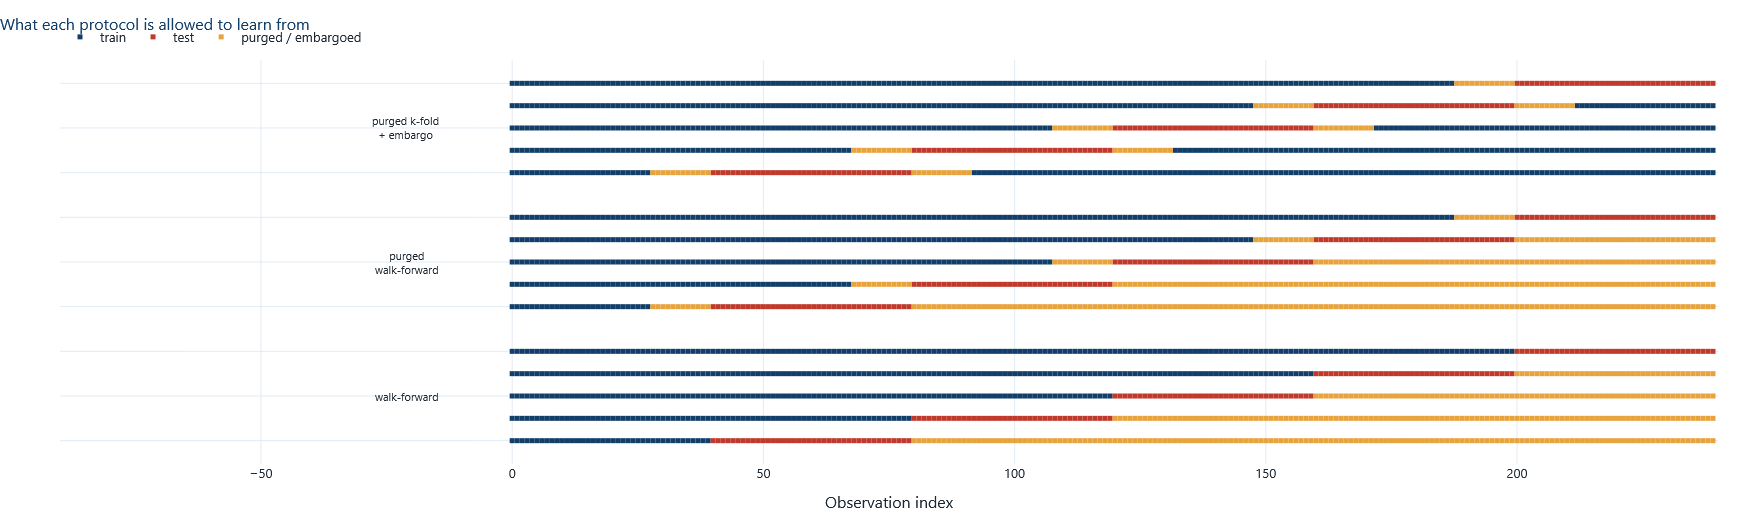

In [23]:
n, S = 240, 5
fig = go.Figure()
for row, (mode, purge, emb) in enumerate([("expanding", 0, 0), ("expanding", 12, 0),
                                          ("kfold", 12, 12)]):
    for k, (tr, te) in enumerate(a.purged_walk_forward(n, n_splits=S, purge=purge,
                                                       embargo=emb, mode=mode)):
        base = row * (S + 1) + k
        covered = np.zeros(n, bool)
        covered[tr] = True
        covered[te] = True
        for arr, colr, nm in [(tr, C["navy"], "train"), (te, C["red"], "test"),
                              (np.where(~covered)[0], C["amber"], "purged / embargoed")]:
            if len(arr) == 0:
                continue
            fig.add_trace(go.Scatter(x=arr, y=[base] * len(arr), mode="markers",
                                     marker=dict(size=5, color=colr, symbol="square"),
                                     showlegend=(row == 0 and k == 0), name=nm,
                                     hoverinfo="skip"))
    fig.add_annotation(x=-14, y=row * (S + 1) + (S - 1) / 2, showarrow=False,
                       xanchor="right", font=dict(size=11, color=C["ink"]),
                       text={0: "walk-forward", 1: "purged<br>walk-forward",
                             2: "purged k-fold<br>+ embargo"}[row])
fig.update_xaxes(title="Observation index", range=[-90, n])
fig.update_yaxes(showticklabels=False, title="")
style(fig, height=520, title="What each protocol is allowed to learn from")
fig.show()

The middle block is the one to study. The amber gap between training and test is the purge: those rows carry labels built from returns that reach into the test period, so they are partly *about* the test period.

The bottom block shows why the embargo exists. Purged k-fold trains on both sides of the test block, which buys more training data at the cost of a boundary on the right that also needs protecting.

## 5. From accuracy to money

An AUC is not a Sharpe ratio. The bridge is the fundamental law of active management: the information ratio you can achieve is the information coefficient you have, multiplied by the square root of the number of independent bets you take.

$$IR \approx IC \times \sqrt{BR}$$

In [24]:
def simulate_ir(ic, br, periods=8000):
    z = rng.standard_normal((periods, br))                    # standardised returns
    s = ic * z + np.sqrt(1 - ic ** 2) * rng.standard_normal((periods, br))
    w = s / np.linalg.norm(s, axis=1, keepdims=True)          # weights follow the signal
    p = (w * z).sum(axis=1)
    return p.mean() / p.std()

check = pd.DataFrame([{"IC": ic, "Breadth": br, "Simulated IR": simulate_ir(ic, br),
                       "IC × √BR": ic * np.sqrt(br)}
                      for ic in [0.02, 0.05, 0.10] for br in [25, 100, 400]])
print(check.to_string(index=False))

   IC  Breadth  Simulated IR  IC × √BR
0.020       25         0.083     0.100
0.020      100         0.194     0.200
0.020      400         0.400     0.400
0.050       25         0.260     0.250
0.050      100         0.516     0.500
0.050      400         0.989     1.000
0.100       25         0.478     0.500
0.100      100         0.995     1.000
0.100      400         2.056     2.000


The law holds to two decimal places. Now read it as a design constraint rather than a formula.

An information coefficient of 0.05 is respectable for an equity signal. To reach an information ratio of 1.0 with it you need four hundred independent bets *per year*. Not four hundred positions — four hundred bets whose outcomes are independent, which correlated equities emphatically are not.

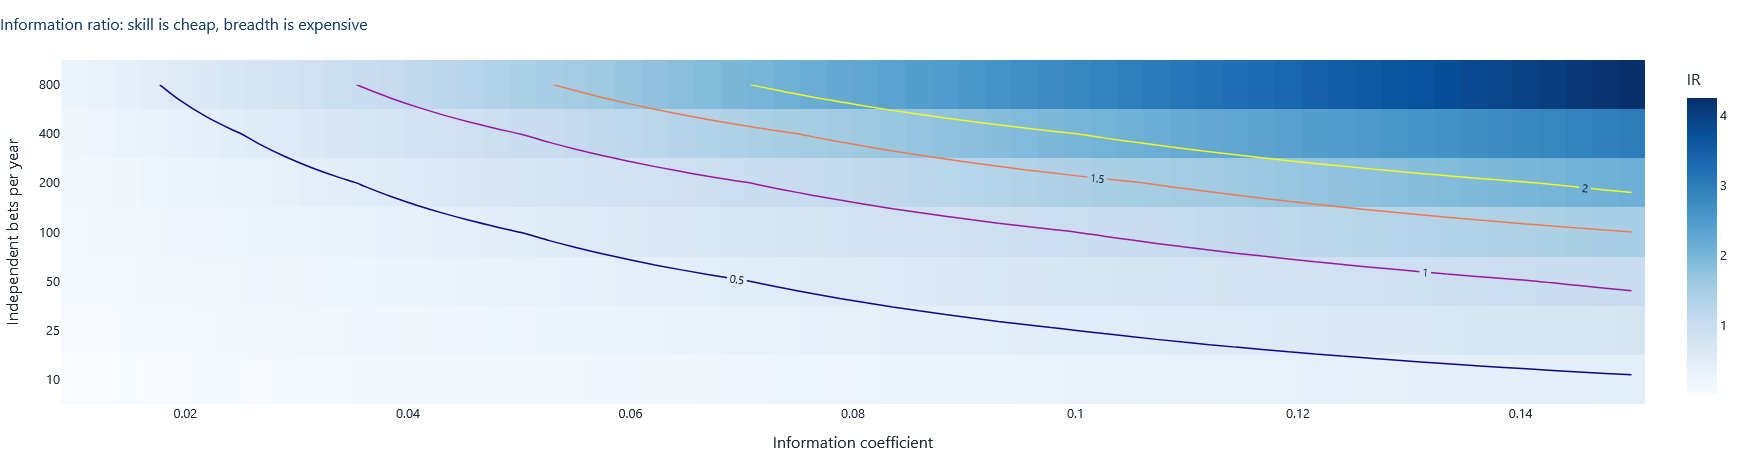

In [25]:
ics = np.linspace(0.01, 0.15, 60)
brs = np.array([10, 25, 50, 100, 200, 400, 800])
grid = np.outer(brs ** 0.5, ics)

fig = go.Figure(go.Heatmap(z=grid, x=ics, y=[str(b) for b in brs],
                           colorscale="Blues", colorbar=dict(title="IR"),
                           hovertemplate="IC %{x:.3f}<br>breadth %{y}<br>"
                                         "IR %{z:.2f}<extra></extra>"))
fig.add_trace(go.Contour(z=grid, x=ics, y=[str(b) for b in brs], showscale=False,
                         contours=dict(start=0.5, end=2.0, size=0.5, coloring="lines",
                                       showlabels=True,
                                       labelfont=dict(size=11, color=C["ink"])),
                         line=dict(color=C["ink"], width=1.5)))
fig.update_xaxes(title="Information coefficient")
fig.update_yaxes(title="Independent bets per year", type="category")
style(fig, height=460, legend_top=False,
      title="Information ratio: skill is cheap, breadth is expensive")
fig.show()

There is a second discount the law does not show. The **transfer coefficient** is the correlation between the positions you wanted and the positions you were able to take, after position limits, liquidity, turnover caps and mandate constraints. It multiplies straight through:

$$IR \approx TC \times IC \times \sqrt{BR}$$

A transfer coefficient of 0.5 — unremarkable for a long-only fund with sector limits — halves everything. Doubling it is usually easier than doubling your skill, and it is a mandate negotiation rather than a research problem.

## 6. The cost ladder

The model produces a signal. Turning it into money requires acting on it, which is where the remaining edge goes. We take the honest walk-forward predictions from §1 and add each real-world friction in turn.

In [26]:
r1 = ohlcv.Close.pct_change().reindex(X.index).fillna(0)

signal = pd.Series(np.nan, index=X.index)
for tr, te in a.purged_walk_forward(len(X), n_splits=6, purge=H):
    proba = model().fit(Xv[tr], yv[tr]).predict_proba(Xv[te])[:, 1]
    signal.iloc[te] = (proba > 0.5).astype(float)
oos = signal.notna()

traded = signal.shift(1)          # decide at today's close, hold from tomorrow
lagged = signal.shift(2)          # one further day before the order actually fills

rungs = [("Walk-forward signal, traded next close", traded, 0),
         ("+ one-day execution lag",                lagged, 0),
         ("+ 2 bp round-trip cost",                 lagged, 2),
         ("+ 5 bp",                                 lagged, 5),
         ("+ 10 bp",                                lagged, 10),
         ("+ 20 bp",                                lagged, 20)]
ladder2 = []
for label, pos, cost in rungs:
    net = (pos * r1 - pos.diff().abs() * cost / 1e4)[oos].dropna()
    ladder2.append({"Rung": label, "Sharpe": a.sharpe(net)})
ladder2 = pd.DataFrame(ladder2)
bh = a.sharpe(r1[oos])
print(ladder2.to_string(index=False))
print(f"\nBuy and hold over the same window : {bh:.2f}")
print(f"Round trips                       : {traded[oos].diff().abs().sum():.0f} "
      f"over {int(oos.sum()):,} days")

                                  Rung  Sharpe
Walk-forward signal, traded next close   0.712
               + one-day execution lag   0.507
                + 2 bp round-trip cost   0.475
                                + 5 bp   0.427
                               + 10 bp   0.348
                               + 20 bp   0.189

Buy and hold over the same window : 0.94
Round trips                       : 128 over 1,014 days


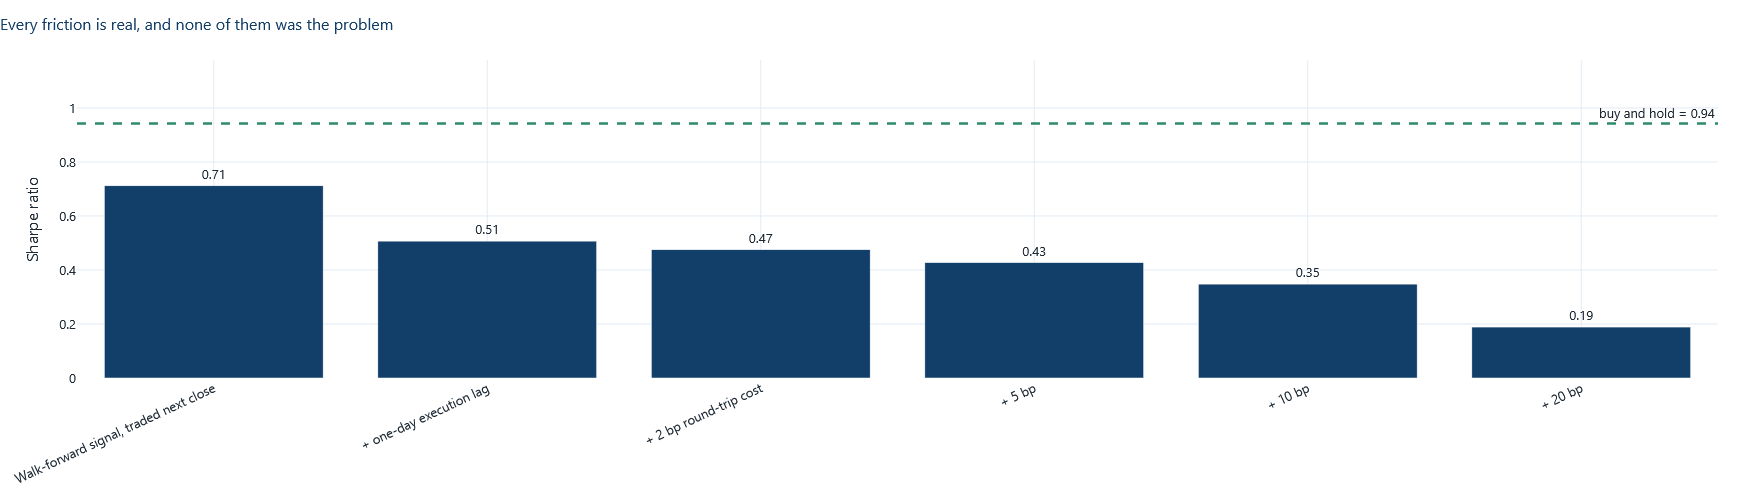

In [27]:
fig = go.Figure()
fig.add_trace(go.Bar(x=ladder2.Rung, y=ladder2.Sharpe, marker_color=C["navy"],
                     text=[f"{v:.2f}" for v in ladder2.Sharpe], textposition="outside"))
fig.add_hline(y=bh, line=dict(color=C["green"], width=2.5, dash="dash"),
              annotation_text=f"buy and hold = {bh:.2f}", annotation_position="top right")
fig.update_yaxes(title="Sharpe ratio", range=[0, max(bh, ladder2.Sharpe.max()) * 1.25])
fig.update_xaxes(tickangle=-25)
style(fig, height=500, legend_top=False,
      title="Every friction is real, and none of them was the problem")
fig.show()

Note where the largest single loss occurs. It is not the trading cost — it is the **one-day execution lag**, which takes 0.22 off the Sharpe ratio on its own. That is more than ten basis points of round-trip cost does, and nearly as much as twenty. A strategy whose edge decays that fast is a strategy about execution speed, not about prediction, and it should be resourced accordingly.

And the dashed line is the verdict. Buy-and-hold beats every rung of the ladder, including the frictionless top one. The honest reading of this whole exercise is that eighty-four features, a gradient-boosted model and a properly purged walk-forward produced something worse than doing nothing.

That is the normal outcome. It is what the literature looks like before publication filters it.

## 7. The probability of backtest overfitting

One last tool, for the situation where you have many candidate strategies rather than one. Combinatorially symmetric cross-validation splits the sample into $S$ blocks, forms every way of assigning half the blocks to training and half to testing, and asks a single question of each: **did the strategy that won in-sample land above or below the median out-of-sample?**

If the selection carries information, the in-sample winner should usually rank well afterwards. The probability of backtest overfitting is the fraction of splits where it does not.

In [28]:
# 84 candidate strategies: each indicator used on its own as a signal.
strategies = {}
for col in X.columns:
    z = (X[col] - X[col].rolling(60).mean()) / X[col].rolling(60).std()
    strategies[col] = (z > 0).astype(float).shift(1) * r1
R = pd.DataFrame(strategies).dropna()

S = 8
blocks = np.array_split(np.arange(len(R)), S)
logits, oos_ranks = [], []
for combo in itertools.combinations(range(S), S // 2):
    tr = np.concatenate([blocks[i] for i in combo])
    te = np.concatenate([blocks[i] for i in range(S) if i not in combo])
    sr_is = R.iloc[tr].mean() / R.iloc[tr].std()
    sr_oos = R.iloc[te].mean() / R.iloc[te].std()
    best = sr_is.idxmax()
    rank = float(np.clip(sr_oos.rank(pct=True)[best], 1e-6, 1 - 1e-6))
    oos_ranks.append(rank)
    logits.append(np.log(rank / (1 - rank)))
logits = np.array(logits)

print(f"Candidate strategies : {R.shape[1]}")
print(f"Splits evaluated     : {len(logits)}  (all {S} choose {S//2} combinations)")
print(f"\nProbability of backtest overfitting : {(logits <= 0).mean():.1%}")
print(f"Median out-of-sample percentile of the in-sample winner : "
      f"{np.median(oos_ranks):.1%}")

Candidate strategies : 84
Splits evaluated     : 70  (all 8 choose 4 combinations)

Probability of backtest overfitting : 50.0%
Median out-of-sample percentile of the in-sample winner : 50.6%


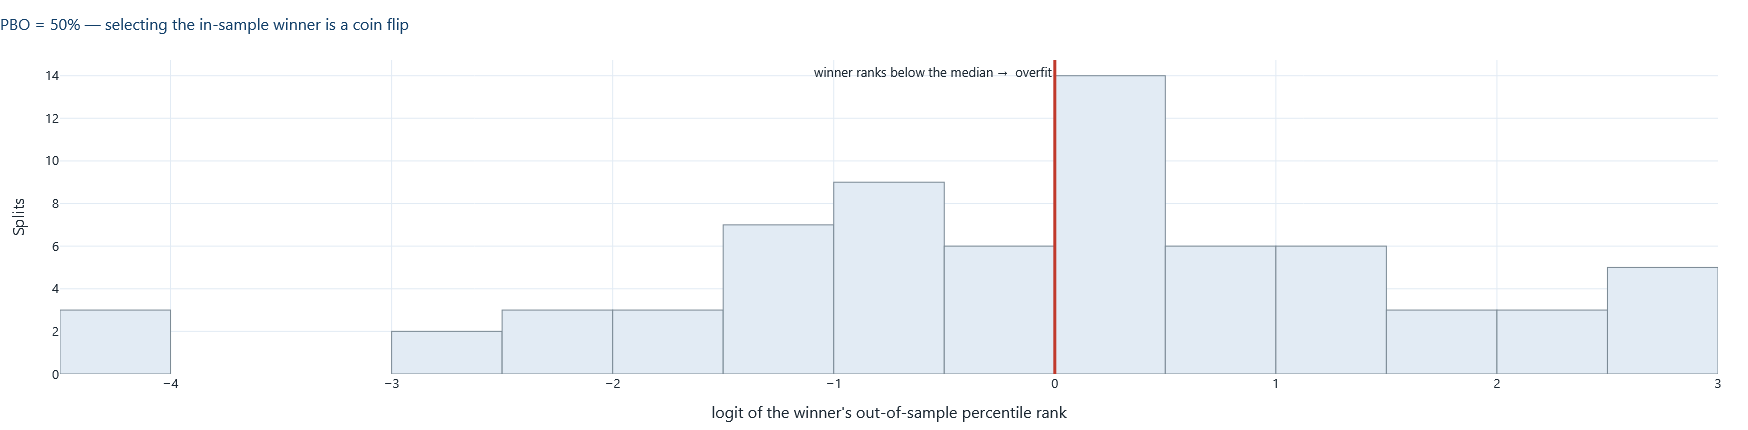

In [29]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=logits, nbinsx=22, marker_color=C["band"],
                           marker_line=dict(color=C["grey"], width=1), name="splits"))
fig.add_vline(x=0, line=dict(color=C["red"], width=3),
              annotation_text="winner ranks below the median →  overfit",
              annotation_position="top left")
fig.update_xaxes(title="logit of the winner's out-of-sample percentile rank")
fig.update_yaxes(title="Splits")
style(fig, height=430, legend_top=False,
      title=f"PBO = {(logits <= 0).mean():.0%} — selecting the in-sample winner is a coin flip")
fig.show()

A PBO of one half is exactly what you get when in-sample ranking carries no information whatsoever about out-of-sample ranking. It is the same finding as the Spearman correlation of −0.31 in Lecture 5a, arrived at from a completely different direction and without needing a single out-of-sample period to be held back.

That last property is what makes CSCV useful in practice. You do not have to sacrifice a hold-out period to get the diagnostic.

## 8. What to take away

1. **The protocol decides the answer.** One model, one dataset, one feature set: AUC 0.80 or AUC 0.51 depending only on how the folds were drawn.
2. **Random k-fold leaks through three separate channels**, and shuffling is by far the largest. The fix everyone reaches for — scaling inside the fold — addresses the smallest.
3. **Report fold dispersion, not just the mean.** Honest folds here ranged from 0.36 to 0.60.
4. **A permutation test cannot detect a leak that permuting destroys.** Ask what your null hypothesis assumes before trusting its p-value.
5. **Purging is necessary; embargoing is necessary only when you train on both sides** of the test block.
6. **Skill is cheap and breadth is expensive.** An IC of 0.05 needs four hundred independent bets for an IR of 1.0, and the transfer coefficient discounts whatever you manage.
7. **Execution lag cost more than 20 bp of trading cost.** Know whether your edge survives a day.
8. **PBO of 50% means the search was a coin flip** — and it is measurable without holding anything back.

The overall result of this notebook is negative: nothing here beat buy-and-hold. That is the honest and typical outcome of a careful evaluation, and being able to reach it reliably is the skill this subject is trying to teach. Publication bias means you will rarely see it written down.

Lecture 5d turns to the one setting where the whole framing changes: when your actions move the thing you are predicting.

## Exercises

**Core**

1. Change the label horizon from 5 days to 20 and re-run the ladder in §1. Does the gap between random k-fold and purged walk-forward widen or narrow? Explain the direction using the overlapping-label argument.
2. In §2, add a sixth protocol: shuffled folds with a *purge* applied inside each fold. Can purging rescue a shuffled split? Say why in one sentence.
3. The cost ladder uses a 0.5 probability threshold. Re-run it requiring the model's confidence to exceed 0.55. What happens to turnover, to the Sharpe ratio, and to the number of days in the market?
4. Compute the information coefficient of the model's predictions directly — the rank correlation between predicted probability and realised forward return — and check whether $IC\sqrt{BR}$ predicts the Sharpe ratio you measured in §6.

**Stretch**

5. Implement the embargo properly for the `mode='kfold'` splitter and measure how large it must be before the AUC stops falling. Compare that number to the label horizon. What does the gap tell you about the autocorrelation of your features?
6. §7 uses each indicator as a standalone signal. Redo the CSCV analysis on 84 *model* variants instead — vary `max_depth`, `learning_rate` and the feature subset. Is the PBO higher or lower, and why would you expect that in advance?
7. The strategy in §6 trades a binary position. Replace it with a position sized by the model's confidence, rebuild the cost ladder, and decide whether sizing bought back any of the lost Sharpe.
8. Take the best single indicator from §7 and compute its deflated Sharpe ratio using `airm5.deflated_sharpe`, counting all 84 candidates as trials. Then argue, in three sentences, whether the DSR or the PBO is the more useful number to put in front of an investment committee.